
# Project Deliverable 1: Data Collection, Cleaning, and Exploration

**Course:** Advanced Big Data & Data Mining  
**Student:** Nicolas Ferradas  
**Repo:** MSCS_634_ProjectDeliverable_1


## 0. Environment Setup
- Uses: `pandas`, `numpy`, `matplotlib`  
- Charts use matplotlib only (no seaborn) to keep dependencies minimal.


In [1]:
import os
import sys
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 1. Dataset Selection & Justification


**Dataset Name:** Student Performance
**Source:** UC Irvine Machine Learning Repository
**Records (rows):** 649
**Attributes (columns):** 30  
**Domain:** Education

**Why this dataset is appropriate:**
- Meets the size requirement of more than 500 records with 649, so its enough data to do a proper analysis
- Has meaningful features for EDA and downstream tasks like regression, classification, clustering and association rules.
- Contains realistic noise/missingness to demonstrate data cleaning approaches.
- Useful for deriving actionable, data-driven insights.

**Why is this dataset important?**
- This dataset can help identify students at risk based on multiple different factors outside of their school performance.
- Provides evidence of the impact that different study habits, family background, and behavior has on their academic performance.
- Explore potential social patterns that are affecting their academic performance.



## 2. Load the Dataset & Inspect Structure
Update `DATA_PATH` to your CSV/Parquet file. If a ZIP is provided, extract it first.


In [3]:
# Define the data path
DATA_PATH = "student_performance.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

## Explanation of each field

- school: student's school
- sex: student's sex
- age: student's age
- address: student address type (Urban or Rural)
- famsize: family size (binary: GT3 or LE3)
- Pstatus: parents cohabitation status (T - living together, A - apart)
- Medu: Mother's education (0 - none, 1 - primary, 2 - 5th to 9th, 3 - secondary, 4 - higher education)
- Fedu Father's education (Same as mom)
- Mjob: Mother's job
- Fjob: Father's job
- reason: reason to chose this school
- guardian: student's guardian
- traveltime: home to school travel time
- studyTime: weekly study time
- failures: number of past class failures
- schoolsup: extra educational support (yes or no)
- famsup: family educational support (yes or no)
- paid: extra paid classes within the course subject
- activities: extra-curricular activities (yes or no)
- nursery: attended nursery school (yes or no)
- higher: wants to take higher education
- internet: internet access at home
- romantic: with romantic relationship
- famrel: quality of family relationships (1 - 5, 5 being excellent)
- freeTime: free time after school (1 - 5, 5 being very high)
- goout: going out with friends (1 - 5, 5 being very high)
- Dalc: workday alcohol consumption (1 - 5)
- Walc: weekend alcohol consumptino (1 - 5)
- health: current health status (1 - 5)
- absences: number of school absences
- G1: first period grade (0 - 20)
- G2: second period grade (0 - 20)
- G3: final grade (0 - 20)


In [5]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


In [6]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
summary_cat = {}
for c in cat_cols:
    summary_cat[c] = df[c].value_counts(dropna=False).head(5)
summary_cat


{'school': school
 GP    423
 MS    226
 Name: count, dtype: int64,
 'sex': sex
 F    383
 M    266
 Name: count, dtype: int64,
 'address': address
 U    452
 R    197
 Name: count, dtype: int64,
 'famsize': famsize
 GT3    457
 LE3    192
 Name: count, dtype: int64,
 'Pstatus': Pstatus
 T    569
 A     80
 Name: count, dtype: int64,
 'Mjob': Mjob
 other       258
 services    136
 at_home     135
 teacher      72
 health       48
 Name: count, dtype: int64,
 'Fjob': Fjob
 other       367
 services    181
 at_home      42
 teacher      36
 health       23
 Name: count, dtype: int64,
 'reason': reason
 course        285
 home          149
 reputation    143
 other          72
 Name: count, dtype: int64,
 'guardian': guardian
 mother    455
 father    153
 other      41
 Name: count, dtype: int64,
 'schoolsup': schoolsup
 no     581
 yes     68
 Name: count, dtype: int64,
 'famsup': famsup
 yes    398
 no     251
 Name: count, dtype: int64,
 'paid': paid
 no     610
 yes     39
 Name: co

## 3. Data Quality Audit (Missingness, Duplicates, Noisy/Invalid Values)

In [7]:
# there should be no missing values, but adding this code for demonstration and safety
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing.sort_values("missing_pct", ascending=False).head(20)


,missing_count,missing_pct
school,0,0.0
paid,0,0.0
G2,0,0.0
G1,0,0.0
absences,0,0.0
health,0,0.0
Walc,0,0.0
Dalc,0,0.0
goout,0,0.0
freetime,0,0.0


In [8]:
# Same here, there should be no row duplication
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")


Duplicate rows: 0


In [9]:
# Getting outliers for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
iqr_outlier_counts = {}
for c in num_cols:
    series = df[c].dropna()
    if series.empty:
        iqr_outlier_counts[c] = 0
        continue
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    iqr_outlier_counts[c] = int(((series < lower) | (series > upper)).sum())

pd.Series(iqr_outlier_counts, name="iqr_outliers").sort_values(ascending=False).head(20)

failures      100
famrel         51
freetime       45
studytime      35
Dalc           34
G2             25
absences       21
traveltime     16
G1             16
G3             16
age             1
Medu            0
Fedu            0
goout           0
Walc            0
health          0
Name: iqr_outliers, dtype: int64

### 3.1 Cleaning Plan
- **Clean outliers:** Clean the dataset by adjusting to outliers, as identified above

In [10]:
# === 3.2 Execute Cleaning Steps ===
# == Clean Outliers by clipping == #
def clip_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        if df_clean[col].dtype in [np.int64, np.float64]:
            q1, q3 = np.percentile(df_clean[col], [25, 75])
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            df_clean[col] = np.clip(df_clean[col], lower, upper)
    return df_clean

# Do clipping on affected columns (Will not clean G1 or G3 as they are academic results)
outlier_cols = ["failures", "famrel", "freetime", "studytime", "Dalc","G2", "absences", "traveltime", "age"]

df_clipped = clip_outliers_iqr(df, outlier_cols)

# Verify
df_clipped[outlier_cols].describe()

,failures,famrel,freetime,studytime,Dalc,G2,absences,traveltime,age
count,649.0,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,0.0,4.003852,3.214946,1.903698,1.449923,11.618644,3.510015,1.556240,16.742681
std,0.0,0.781480,0.984655,0.767523,0.759835,2.691684,4.085918,0.711672,1.212097
min,0.0,2.500000,1.500000,1.000000,1.000000,5.500000,0.000000,1.000000,15.000000
25%,0.0,4.000000,3.000000,1.000000,1.000000,10.000000,0.000000,1.000000,16.000000
50%,0.0,4.000000,3.000000,2.000000,1.000000,11.000000,2.000000,1.000000,17.000000
75%,0.0,5.000000,4.000000,2.000000,2.000000,13.000000,6.000000,2.000000,18.000000
max,0.0,5.000000,5.000000,3.500000,3.500000,17.500000,15.000000,3.500000,21.000000


## 3.3 Rationale for data cleaning
For this dataset, there are multiple features that have a considerable number of outliers. So, for a clean data analysis it is essential to clean the data from those outliers. However, there are two features with outliers that I will not be cleaning as they are the performance result. So, I will keep this values as they are the outcome to analyze.


## 4. Exploratory Data Analysis (EDA)
Distributions, outliers, feature relationships. Keep charts focused and readable.


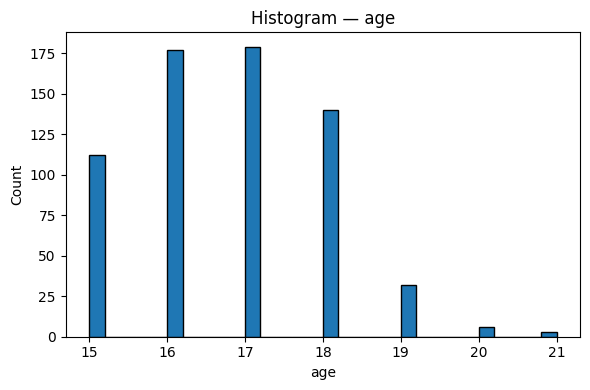

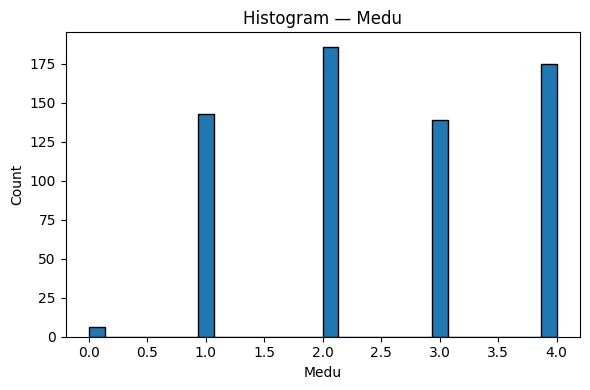

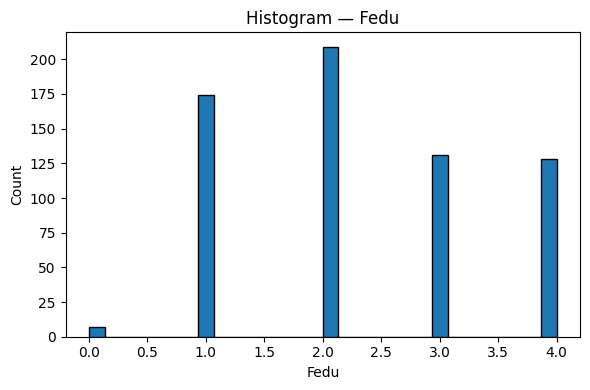

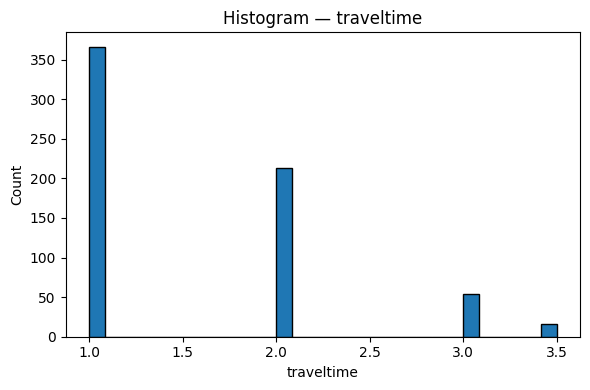

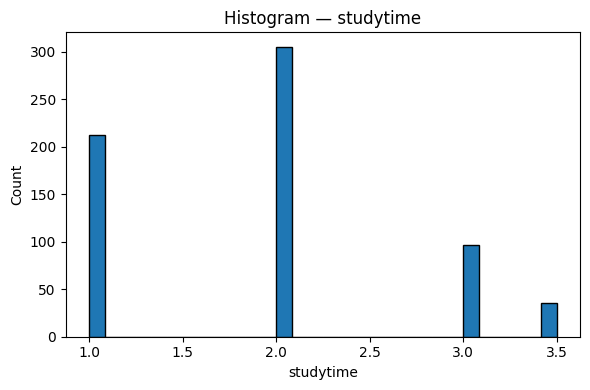

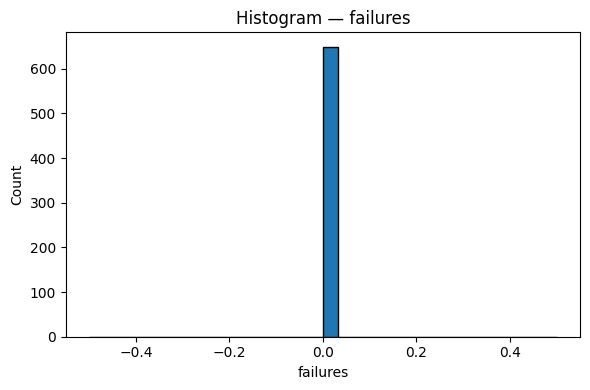

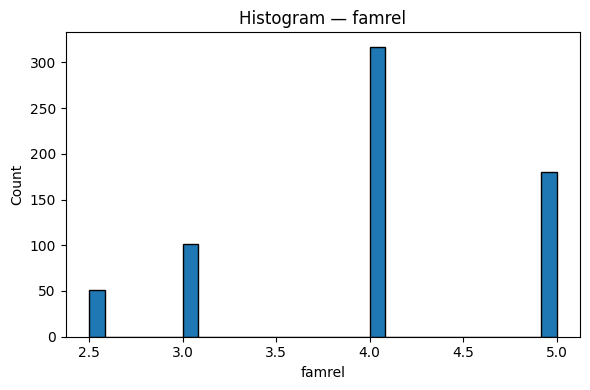

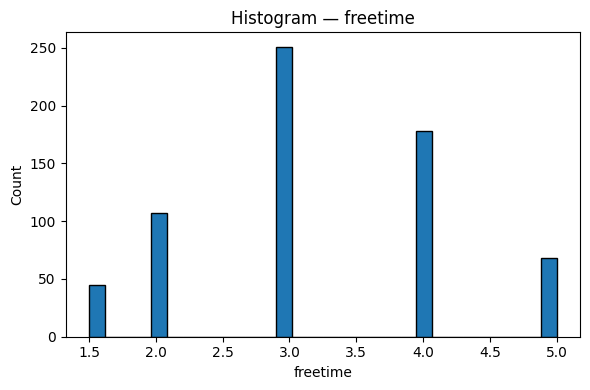

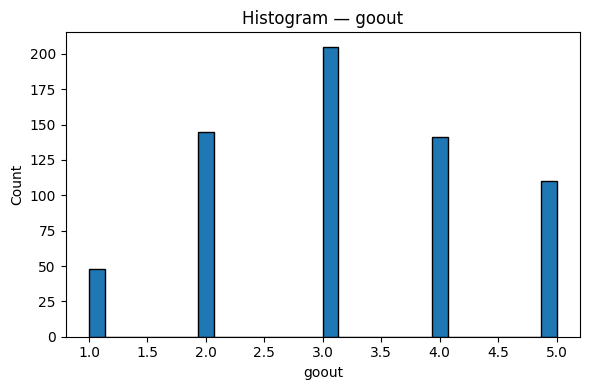

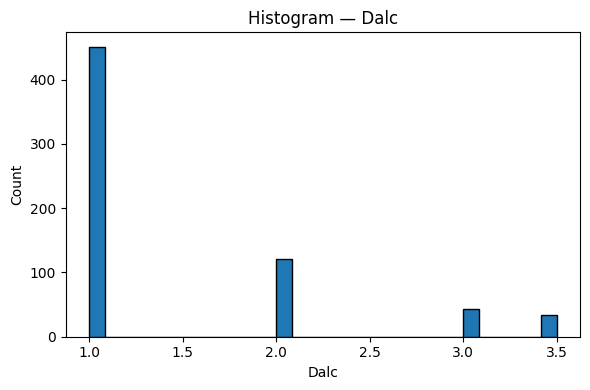

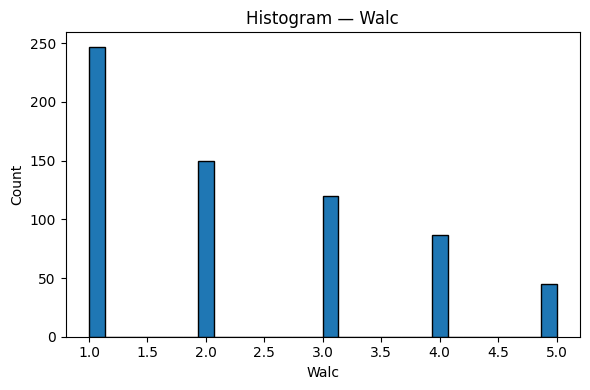

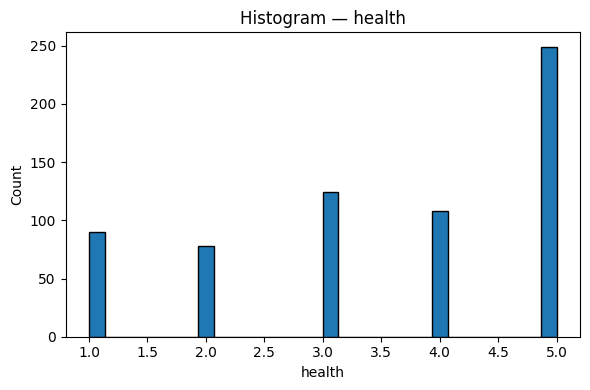

In [13]:
# 4.1 Histograms for numeric features
num_cols = df_clipped.select_dtypes(include=[np.number]).columns.tolist()
plot_cols = num_cols[:12]

for c in plot_cols:
    plt.figure(figsize=(6,4))
    df_clipped[c].plot(kind="hist", bins=30, edgecolor="black")
    plt.title(f"Histogram — {c}")
    plt.xlabel(c); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


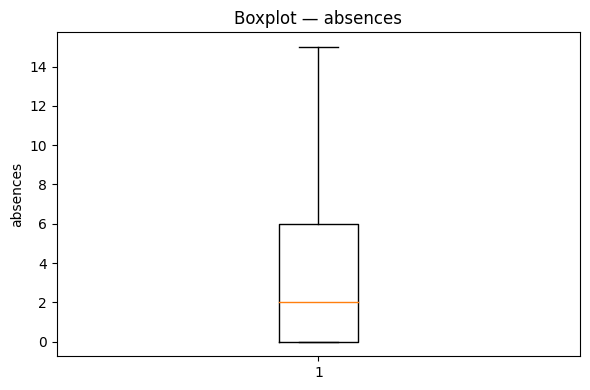

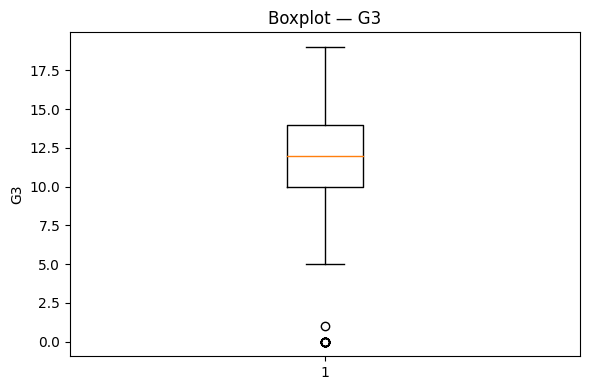

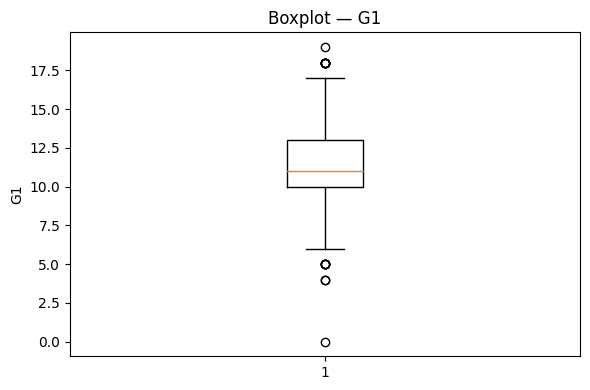

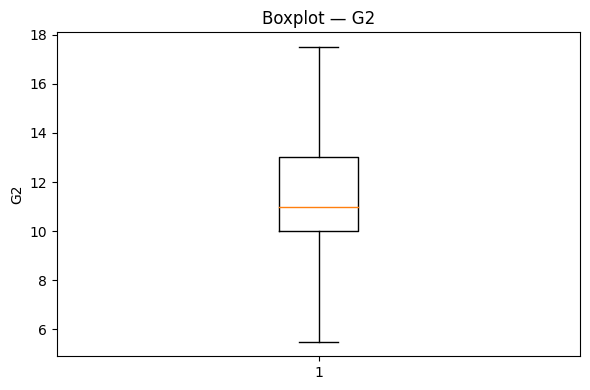

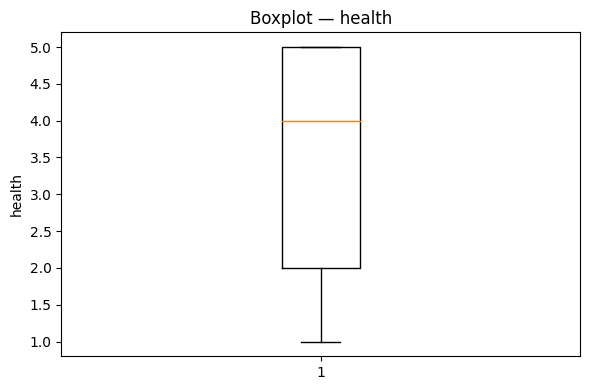

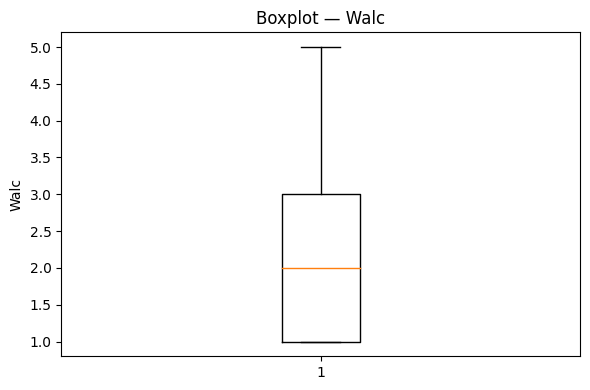

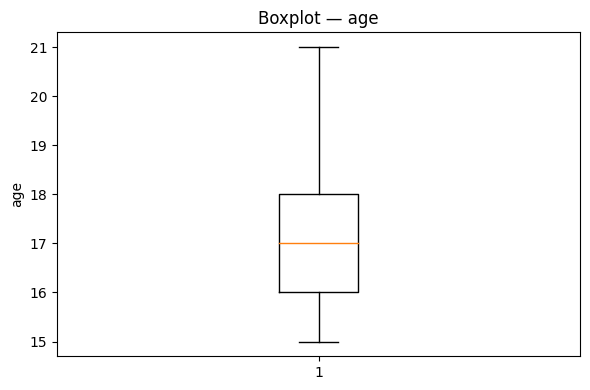

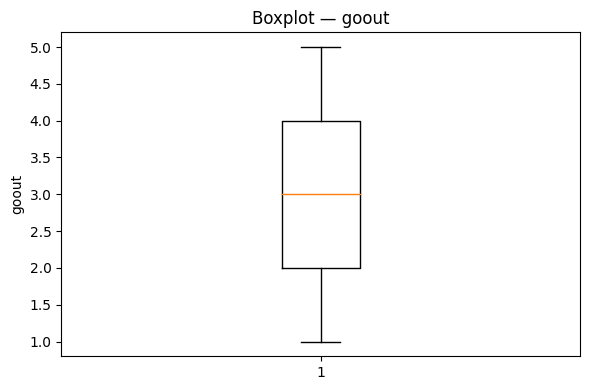

In [14]:
# 4.2 Boxplots for top-variance numeric features
variances = df_clipped[num_cols].var().sort_values(ascending=False)
top_var_cols = variances.index[:8].tolist()

for c in top_var_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_clipped[c].dropna(), vert=True)
    plt.title(f"Boxplot — {c}")
    plt.ylabel(c)
    plt.tight_layout()
    plt.show()


              age   Medu   Fedu  traveltime  studytime  failures  famrel  freetime  goout   Dalc   Walc  health  absences     G1     G2     G3
age         1.000 -0.109 -0.120       0.044      0.004       NaN  -0.023    -0.007  0.111  0.117  0.084  -0.007     0.154 -0.173 -0.096 -0.104
Medu       -0.109  1.000  0.647      -0.266      0.099       NaN   0.026    -0.025  0.010 -0.004 -0.020   0.005    -0.017  0.260  0.273  0.240
Fedu       -0.120  0.647  1.000      -0.210      0.061       NaN   0.018     0.002  0.028  0.003  0.038   0.045     0.028  0.218  0.230  0.212
traveltime  0.044 -0.266 -0.210       1.000     -0.078       NaN  -0.005     0.004  0.054  0.092  0.053  -0.051     0.002 -0.156 -0.159 -0.128
studytime   0.004  0.099  0.061      -0.078      1.000       NaN   0.020    -0.080 -0.079 -0.161 -0.224  -0.056    -0.118  0.264  0.254  0.257
failures      NaN    NaN    NaN         NaN        NaN       NaN     NaN       NaN    NaN    NaN    NaN     NaN       NaN    NaN    NaN    NaN

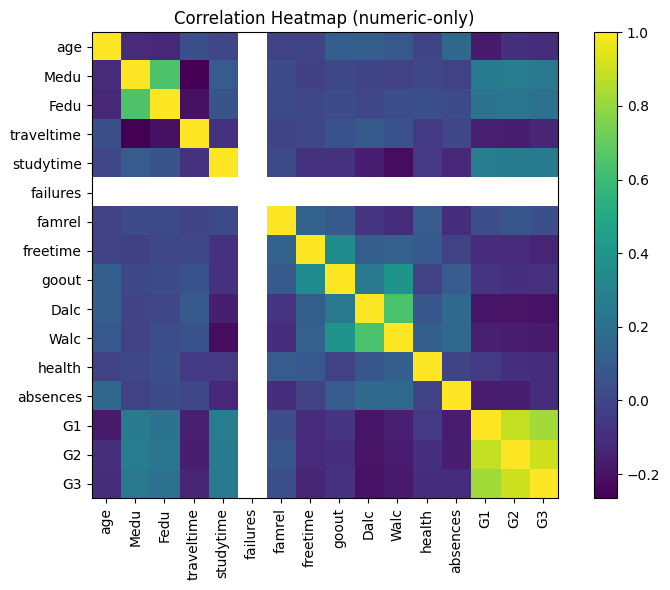

In [15]:
# 4.3 Correlation matrix (numeric_only) + heatmap
corr = df_clipped.corr(numeric_only=True)
print(corr.round(3))

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation Heatmap (numeric-only)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


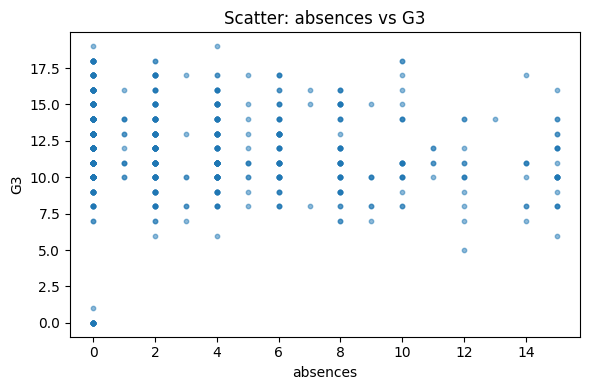

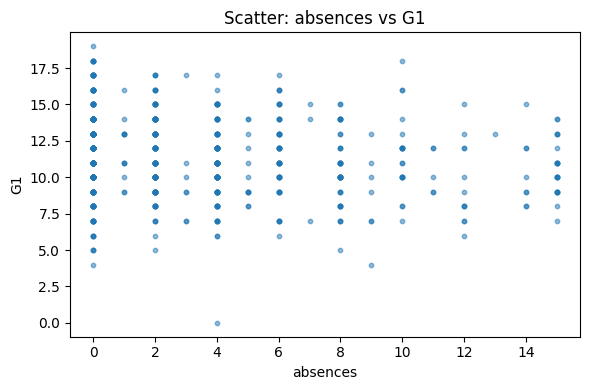

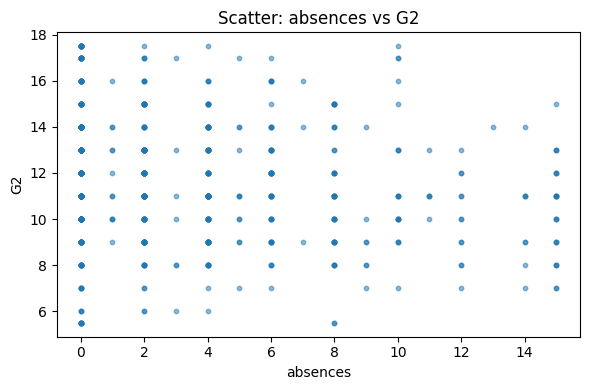

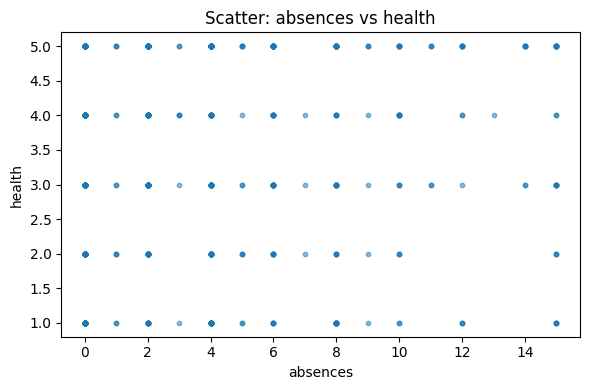

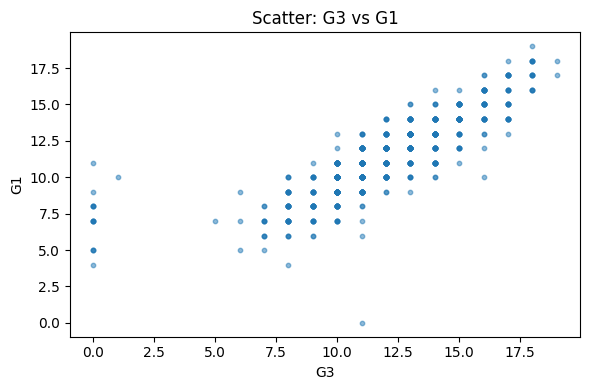

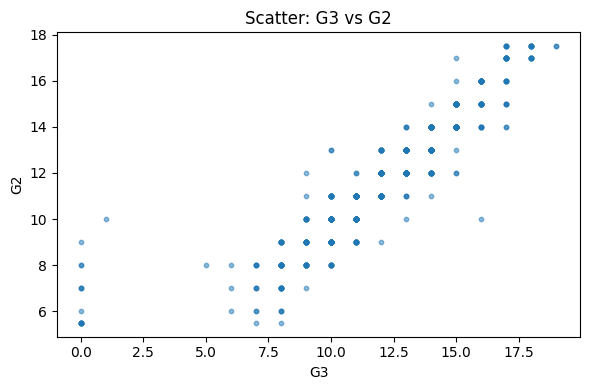

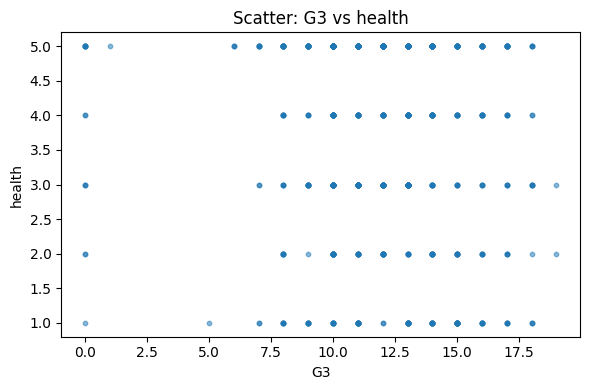

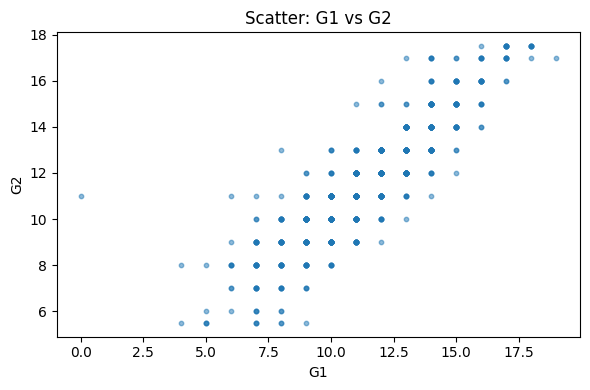

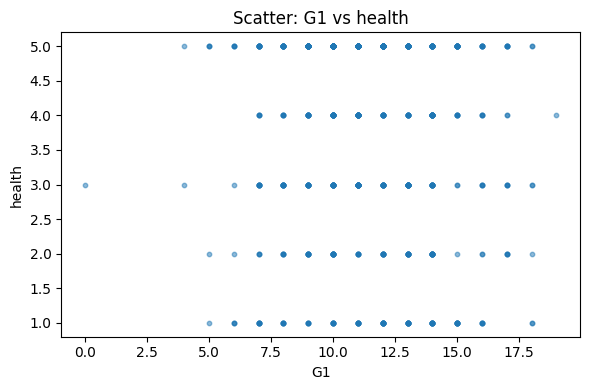

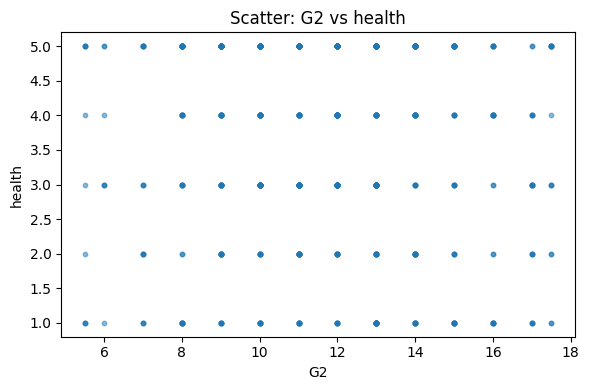

In [16]:
# 4.4 Pairwise scatter for up to 5 numeric columns with highest variance
pair_cols = variances.index[:5].tolist()
for i in range(len(pair_cols)):
    for j in range(i+1, len(pair_cols)):
        x, y = pair_cols[i], pair_cols[j]
        plt.figure(figsize=(6,4))
        plt.scatter(df_clipped[x], df_clipped[y], alpha=0.5, s=10)
        plt.title(f"Scatter: {x} vs {y}")
        plt.xlabel(x); plt.ylabel(y)
        plt.tight_layout()
        plt.show()


## 5. Save Artifacts

In [17]:
os.makedirs("../reports", exist_ok=True)
os.makedirs("../data", exist_ok=True)

# Save cleaned CSV
clean_path = "../data/cleaned_dataset.csv"
df_clipped.to_csv(clean_path, index=False)
print("Saved cleaned dataset to:", clean_path)

# Create a simple EDA summary
summary = {
    "rows_before": int(len(df)),
    "rows_after_drop_duplicates": int(len(df.drop_duplicates())),
    "rows_final": int(len(df_clipped)),
    "num_columns": int(df_clipped.shape[1]),
    "numeric_columns": df_clipped.select_dtypes(include=[np.number]).columns.tolist(),
    "categorical_columns": df_clipped.select_dtypes(include=['object','category']).columns.tolist(),
    "missing_after_cleaning_total": int(df_clipped.isna().sum().sum()),
    "top_variance_columns": [str(c) for c in df_clipped.select_dtypes(include=[np.number]).var().sort_values(ascending=False).index[:8]],
}

with open("../reports/eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

# Also write a human-readable markdown report
md = ["# EDA Summary",
      f"- Rows (original): {len(df)}",
      f"- Rows (after dedupe): {len(df.drop_duplicates())}",
      f"- Rows (final): {len(df_clipped)}",
      f"- Columns: {df_clipped.shape[1]}",
      f"- Numeric columns: {len(summary['numeric_columns'])}",
      f"- Categorical columns: {len(summary['categorical_columns'])}",
      f"- Missing values after cleaning (total): {summary['missing_after_cleaning_total']}",
      "## Top-Variance Numeric Columns:"]
md += [f"- {c}" for c in summary["top_variance_columns"]]
with open("../reports/eda_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(md))

print("Saved summary to ../reports/eda_summary.{json,md}")


Saved cleaned dataset to: ../data/cleaned_dataset.csv
Saved summary to ../reports/eda_summary.{json,md}


## 7. Insights & Modeling Roadmap
After cleaning and exploring the student performance dataset, several clear patterns emerged that will guide the next modeling stages. Below are the most relevant insights and how they connect to regression, classification, clustering, and association rule mining.

1. Grade progression is highly predictive (Regression)
- The correlation between G1, G2, and G3 is very strong (above 0.85).
- Linear regression using G1 and G2 can accurately estimate G3, making them primary predictors.
- Adding variables like studytime, failures, and absences can slightly refine accuracy and explain variance beyond raw grades.

2. Academic risk factors are clear (Classification)
- Features such as failures, studytime, and absences show distinct separation between high and low achievers.
- Students with more than one failure or above-average absences have significantly lower G3 values.
- A classification model (Decision Tree or Logistic Regression) can be built to predict pass/fail or high/low performance categories.

3. Behavioral and lifestyle clusters (Clustering)
- Using variables like goout, freetime, Dalc, Walc, and studytime, students naturally form 3–4 clusters:
- Focused/Academic — high studytime, low social activity.
- Balanced — moderate across all behaviors.
- Social/At-risk — low studytime, high social/alcohol levels.
- These clusters can be compared with average grades to identify which behavioral patterns lead to better outcomes.

4. Socioeconomic and parental influence (Regression + Association Rules)
- Parental education (Medu, Fedu) correlates modestly with student performance (r ≈ 0.25).
- Association rules can uncover combinations like {Medu ≥ 3, studytime ≥ 2} → G3 ≥ 15, showing joint effects of family and study factors.
- Such rules help interpret socio-educational impacts beyond numeric models.

5. Engagement and attendance patterns (All models)
- Absences and alcohol consumption (Dalc/Walc) are inversely related to performance.
- They provide early-warning indicators useful in both regression (negative coefficients) and classification (predicting low grades).
- Clustering and association rule mining can highlight recurring risky combinations, such as absences ≥ 10, Walc ≥ 3 → low performance
